In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU Device: Tesla T4
GPU Memory: 15.83 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
project_dir = '/content/drive/MyDrive/circuit_detection_project'
os.makedirs(project_dir, exist_ok=True)
os.chdir(project_dir)
print(f"Working directory: {os.getcwd()}")

Working directory: /content/drive/MyDrive/circuit_detection_project


In [ ]:
!pip install -q opencv-python-headless
!pip install -q albumentations
!pip install -q ultralytics 
!pip install -q torchmetrics
!pip install -q opendatasets 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.8 MB/s eta 0:00:00


In [9]:
from google.colab import files
uploaded = files.upload()

Saving handdrawn-circuit-schematic-components.zip to handdrawn-circuit-schematic-components.zip


In [11]:
!unzip -q handdrawn-circuit-schematic-components.zip -d dataset

In [12]:
directories = [
    'data/raw',
    'data/processed',
    'data/augmented',
    'models/baseline',
    'models/cnn',
    'models/yolo',
    'results/template_matching',
    'results/sift',
    'results/cnn',
    'results/yolo',
    'notebooks',
    'utils'
]

for dir_path in directories:
    os.makedirs(dir_path, exist_ok=True)

print("✓ Directory structure created!")


✓ Directory structure created!


Total images found: 2952


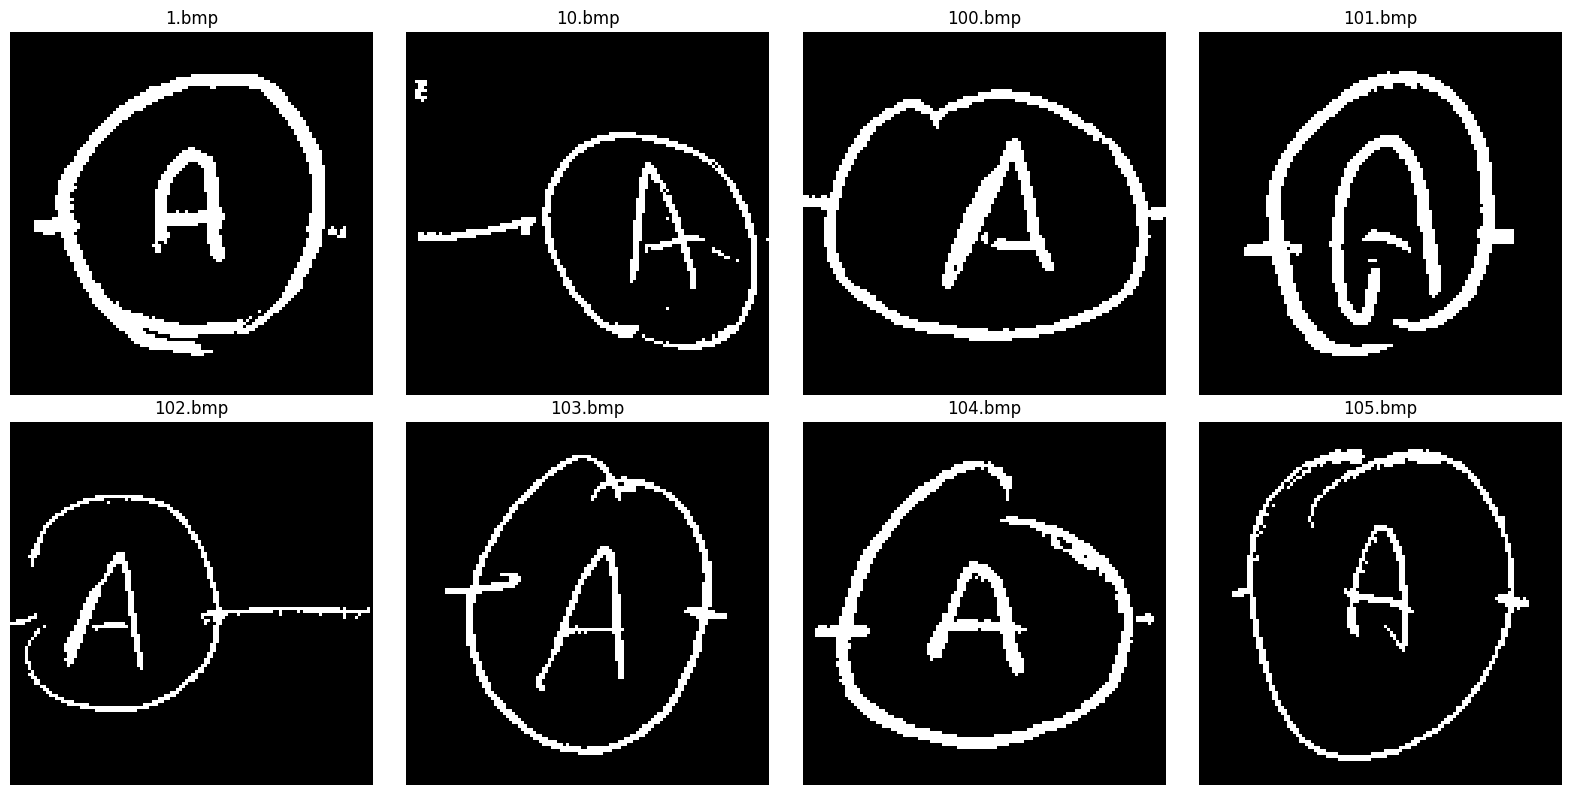

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

dataset_path = Path('dataset')
image_files = (list(dataset_path.rglob('*.png')) +
               list(dataset_path.rglob('*.jpg')) +
               list(dataset_path.rglob('*.bmp')) +
               list(dataset_path.rglob('*.BMP')))
print(f"Total images found: {len(image_files)}")


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, img_path in enumerate(image_files[:8]):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(img_path.name)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

classes = set()
for img_path in image_files:
    class_name = img_path.parent.name
    classes.add(class_name)

classes = sorted(list(classes))
print(f"\nClasses found ({len(classes)}):")
for i, cls in enumerate(classes, 1):
  
    count = len(list(dataset_path.rglob(f'{cls}/*.png'))) + \
            len(list(dataset_path.rglob(f'{cls}/*.jpg'))) + \
            len(list(dataset_path.rglob(f'{cls}/*.jpeg'))) + \
            len(list(dataset_path.rglob(f'{cls}/*.bmp')))
    print(f"  {i}. {cls}: {count} images")


import json
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

with open('data/class_mapping.json', 'w') as f:
    json.dump({'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class}, f, indent=2)

print(f"\n✓ Class mapping saved!")


Classes found (15):
  1. Ammeter: 200 images
  2. ac_src: 199 images
  3. battery: 200 images
  4. cap: 200 images
  5. curr_src: 200 images
  6. dc_volt_src_1: 199 images
  7. dc_volt_src_2: 199 images
  8. dep_curr_src: 197 images
  9. dep_volt: 196 images
  10. diode: 200 images
  11. gnd_1: 182 images
  12. gnd_2: 198 images
  13. inductor: 194 images
  14. resistor: 188 images
  15. voltmeter: 200 images

✓ Class mapping saved!


In [ ]:
import shutil
from sklearn.model_selection import train_test_split


organized_data = {}
for img_path in image_files:
    class_name = img_path.parent.name
    if class_name not in organized_data:
        organized_data[class_name] = []
    organized_data[class_name].append(str(img_path))

train_images = []
val_images = []
test_images = []

for class_name, images in organized_data.items():
    if len(images) < 3:
        print(f"Warning: {class_name} has only {len(images)} images")
        train_images.extend([(img, class_name) for img in images])
        continue

    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    train_images.extend([(img, class_name) for img in train])
    val_images.extend([(img, class_name) for img in val])
    test_images.extend([(img, class_name) for img in test])

print(f"\nDataset split:")
print(f"  Train: {len(train_images)} images")
print(f"  Val: {len(val_images)} images")
print(f"  Test: {len(test_images)} images")


for split_name, split_data in [('train', train_images), ('val', val_images), ('test', test_images)]:
    for img_path, class_name in split_data:
        dest_dir = f'data/processed/{split_name}/{class_name}'
        os.makedirs(dest_dir, exist_ok=True)
        dest_path = os.path.join(dest_dir, Path(img_path).name)
        shutil.copy2(img_path, dest_path)

print("✓ Dataset organized into train/val/test splits!")


Dataset split:
  Train: 2062 images
  Val: 443 images
  Test: 447 images
✓ Dataset organized into train/val/test splits!


In [ ]:

preprocessing_code = '''
import cv2
import numpy as np

def preprocess_image(image_path, target_size=(224, 224)):
    """
    Standard preprocessing for circuit symbols
    """
    # Read image
    img = cv2.imread(image_path)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply bilateral filter to reduce noise while keeping edges
    filtered = cv2.bilateralFilter(gray, 9, 75, 75)

    # Adaptive thresholding
    binary = cv2.adaptiveThreshold(filtered, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)

    # Resize
    resized = cv2.resize(binary, target_size)

    # Normalize to [0, 1]
    normalized = resized / 255.0

    return normalized, gray, binary

def extract_bounding_box(binary_image):
    """
    Extract bounding box of the symbol
    """
    # Find contours
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    # Get largest contour
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box
    x, y, w, h = cv2.boundingRect(largest_contour)

    return (x, y, w, h)
'''

with open('utils/preprocessing.py', 'w') as f:
    f.write(preprocessing_code)

print("✓ Preprocessing utilities created!")

✓ Preprocessing utilities created!


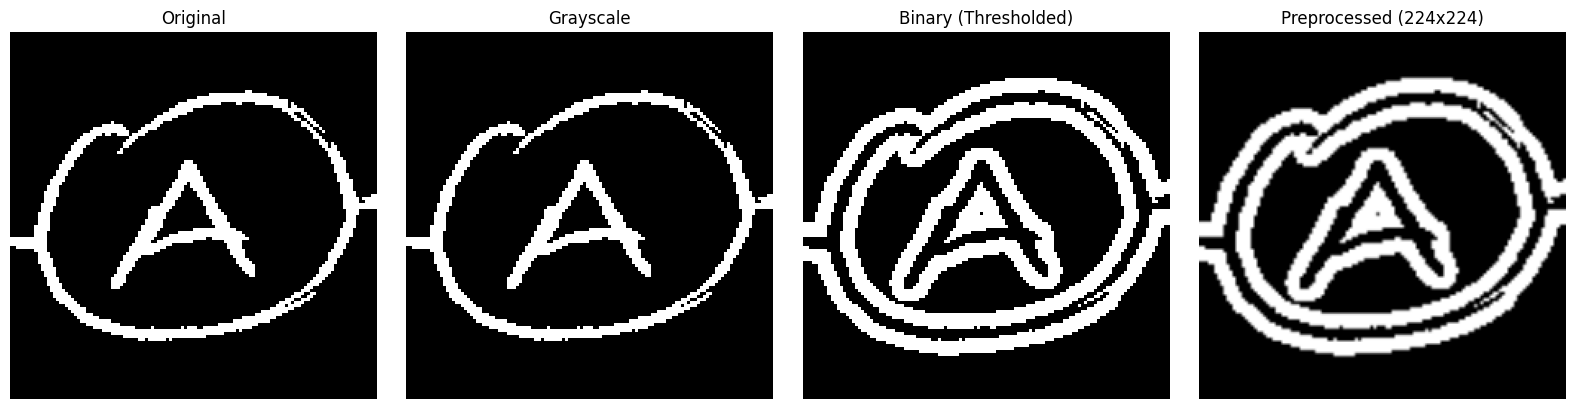

✓ Preprocessing visualization saved!


In [ ]:
import sys
sys.path.append('utils')
from preprocessing import preprocess_image, extract_bounding_box

sample_img = train_images[0][0]
normalized, gray, binary = preprocess_image(sample_img)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
original = cv2.imread(sample_img)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

# Grayscale
axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

# Binary
axes[2].imshow(binary, cmap='gray')
axes[2].set_title('Binary (Thresholded)')
axes[2].axis('off')

# Normalized & Resized
axes[3].imshow(normalized, cmap='gray')
axes[3].set_title('Preprocessed (224x224)')
axes[3].axis('off')

plt.tight_layout()
plt.savefig('results/preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Preprocessing visualization saved!")

In [26]:
stats = {
    'total_images': len(image_files),
    'num_classes': len(classes),
    'classes': classes,
    'train_size': len(train_images),
    'val_size': len(val_images),
    'test_size': len(test_images),
    'image_format': 'PNG/JPG',
    'preprocessing': 'Grayscale, Binary Threshold, Resize to 224x224'
}

with open('data/dataset_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print("\n" + "="*60)
print("SETUP COMPLETE! ✓")
print("="*60)
print(f"Project directory: {project_dir}")
print(f"Total classes: {len(classes)}")
print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")
print(f"Test images: {len(test_images)}")
print("\nNext step: Run the Baseline Models notebook (Template Matching + SIFT)")
print("="*60)


SETUP COMPLETE! ✓
Project directory: /content/drive/MyDrive/circuit_detection_project
Total classes: 15
Training images: 2062
Validation images: 443
Test images: 447

Next step: Run the Baseline Models notebook (Template Matching + SIFT)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from tqdm import tqdm
import pickle
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns


with open('data/class_mapping.json', 'r') as f:
    class_data = json.load(f)
    class_to_idx = class_data['class_to_idx']
    idx_to_class = {int(k): v for k, v in class_data['idx_to_class'].items()}

print(f"Loaded {len(class_to_idx)} classes")

Loaded 15 classes


In [ ]:


class TemplateMatchingClassifier:
    def __init__(self, method=cv2.TM_SQDIFF_NORMED):
        self.method = method
        self.templates = {}
        self.class_names = []

    def train(self, train_dir):
        print("\n[Template Matching] Creating templates...")
        train_path = Path(train_dir)
        self.class_names = sorted([p.name for p in train_path.iterdir() if p.is_dir()])

        for class_name in tqdm(self.class_names):
            class_dir = train_path / class_name
            images = []

            for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.BMP']:
                for img_path in class_dir.glob(ext):
                    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                    if img is None:
                        continue

                    img = cv2.resize(img, (128, 128))

                    images.append(img)

            if images:
                template = np.median(images, axis=0).astype(np.uint8)
                self.templates[class_name] = template
            else:
                print(f"⚠️ No images found for class '{class_name}'")

        print(f"✓ Created {len(self.templates)} templates")

    def predict(self, image_path):
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None, 0

        img = cv2.resize(img, (128, 128))


        best_score = 1.0  
        best_class = None

        for class_name, template in self.templates.items():
            result = cv2.matchTemplate(img, template, self.method)
            score = result[0][0]

            if score < best_score:
                best_score = score
                best_class = class_name

        return best_class, best_score

    def evaluate(self, test_dir):
        print("\n[Template Matching] Evaluating...")
        test_path = Path(test_dir)

        y_true, y_pred = [], []

        for class_name in self.class_names:
            class_dir = test_path / class_name

            for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.BMP']:
                for img_path in class_dir.glob(ext):
                    pred_class, _ = self.predict(img_path)

                    if pred_class is not None:
                        y_true.append(class_name)
                        y_pred.append(pred_class)

        if not y_true:
            print("⚠️ No predictions made! Check your paths or preprocessing.")
            return None

        cm = confusion_matrix(y_true, y_pred, labels=self.class_names)
        print("Confusion Matrix:\n", cm)

        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted', zero_division=0
        )

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm.tolist(),
            'y_true': y_true,
            'y_pred': y_pred
        }


In [ ]:
tm_classifier = TemplateMatchingClassifier()   
tm_classifier.train('data/processed/train')    



[Template Matching] Creating templates...


100%|██████████| 15/15 [00:13<00:00,  1.14it/s]

✓ Created 15 templates


In [93]:
print(type(results))
print(results)

<class 'ultralytics.utils.metrics.DetMetrics'>
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  5,  6,  7,  8, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c0a2b407fe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,  

In [ ]:
class SIFTClassifier:

    def __init__(self, n_features=500):
        self.sift = cv2.SIFT_create(nfeatures=n_features)
        self.bf_matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
        self.class_features = {}
        self.class_names = []

    def extract_features(self, image_path):
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if img is None: return None, None
        img = cv2.resize(img, (256, 256))
        keypoints, descriptors = self.sift.detectAndCompute(img, None)
        return keypoints, descriptors

    def train(self, train_dir):
        print("\n[SIFT] Extracting features from training data...")
        train_path = Path(train_dir)

        for class_name in tqdm(class_to_idx.keys()):
            class_dir = train_path / class_name
            if not class_dir.exists():
                continue

            class_descriptors = []

            for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.BMP']:
                for img_path in class_dir.glob(ext):
                    _, descriptors = self.extract_features(img_path)
                    if descriptors is not None and descriptors.shape[0] > 0:
                        class_descriptors.append(descriptors)

            if len(class_descriptors) > 0:
                combined_descriptors = np.vstack(class_descriptors)
                self.class_features[class_name] = combined_descriptors
                self.class_names.append(class_name)

        print(f"Extracted features for {len(self.class_features)} classes")

    def predict(self, image_path):

        _, query_desc = self.extract_features(image_path)

        if query_desc is None or query_desc.shape[0] == 0:
            return None, 0

        best_score = 0
        best_class = None

        for class_name, train_desc in self.class_features.items():
            if train_desc.shape[0] < 2:
                continue

            matches = self.bf_matcher.knnMatch(query_desc, train_desc, k=2)

            good_matches = []
            for m_n in matches:
                if len(m_n) == 2:
                    m, n = m_n
                    if m.distance < 0.75 * n.distance:
                        good_matches.append(m)

            score = len(good_matches)

            if score > best_score:
                best_score = score
                best_class = class_name

        return best_class, best_score

    def evaluate(self, test_dir):
        print("\n[SIFT] Evaluating...")
        test_path = Path(test_dir)

        y_true = []
        y_pred = []

        for class_name in tqdm(class_to_idx.keys()):
            class_dir = test_path / class_name
            if not class_dir.exists():
                continue

            for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.BMP']:
                for img_path in class_dir.glob(ext):
                    pred_class, score = self.predict(img_path)
                    y_true.append(class_name)
                    y_pred.append(pred_class if pred_class else 'unknown')

        if len(y_true) == 0:
            print("Warning: No test images were processed!")
            return {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1_score': 0, 'y_true': [], 'y_pred': []}

        all_labels = sorted(list(set(y_true + y_pred)))

        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted', zero_division=0, labels=all_labels
        )

        results = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'y_true': y_true,
            'y_pred': y_pred
        }

        return results

In [ ]:
sift_classifier = SIFTClassifier(n_features=500)
sift_classifier.train('data/processed/train')

sift_results = sift_classifier.evaluate('data/processed/test')

print("\n" + "="*60)
print("SIFT FEATURE MATCHING RESULTS")
print("="*60)
print(f"Accuracy:  {sift_results['accuracy']:.4f}")
print(f"Precision: {sift_results['precision']:.4f}")
print(f"Recall:    {sift_results['recall']:.4f}")
print(f"F1-Score:  {sift_results['f1_score']:.4f}")
print("="*60)

with open('results/sift/results.json', 'w') as f:
    json.dump({k: v for k, v in sift_results.items() if k not in ['y_true', 'y_pred']}, f, indent=2)

sift_obj = getattr(sift_classifier, 'sift', None)
matcher_obj = getattr(sift_classifier, 'bf_matcher', None) 

sift_classifier.sift = None
sift_classifier.bf_matcher = None 

with open('models/baseline/sift.pkl', 'wb') as f:
    pickle.dump(sift_classifier, f)

sift_classifier.sift = sift_obj
sift_classifier.bf_matcher = matcher_obj 
print("✓ SIFT Model saved successfully to models/baseline/sift.pkl")


[SIFT] Extracting features from training data...


100%|██████████| 15/15 [01:01<00:00,  4.12s/it]


✓ Extracted features for 15 classes

[SIFT] Evaluating...


100%|██████████| 15/15 [18:23<00:00, 73.56s/it]



SIFT FEATURE MATCHING RESULTS
Accuracy:  0.2260
Precision: 0.2639
Recall:    0.2260
F1-Score:  0.2306
✓ SIFT Model saved successfully to models/baseline/sift.pkl


In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, title, save_path):

    unique_labels = sorted(list(set(y_true + y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_labels, yticklabels=unique_labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show() 

plot_confusion_matrix(
    tm_results['y_true'],
    tm_results['y_pred'],
    list(class_to_idx.keys()),
    'Template Matching - Confusion Matrix',
    'results/template_matching/confusion_matrix.png'
)

plot_confusion_matrix(
    sift_results['y_true'],
    sift_results['y_pred'],
    list(class_to_idx.keys()),
    'SIFT Feature Matching - Confusion Matrix',
    'results/sift/confusion_matrix.png'
)

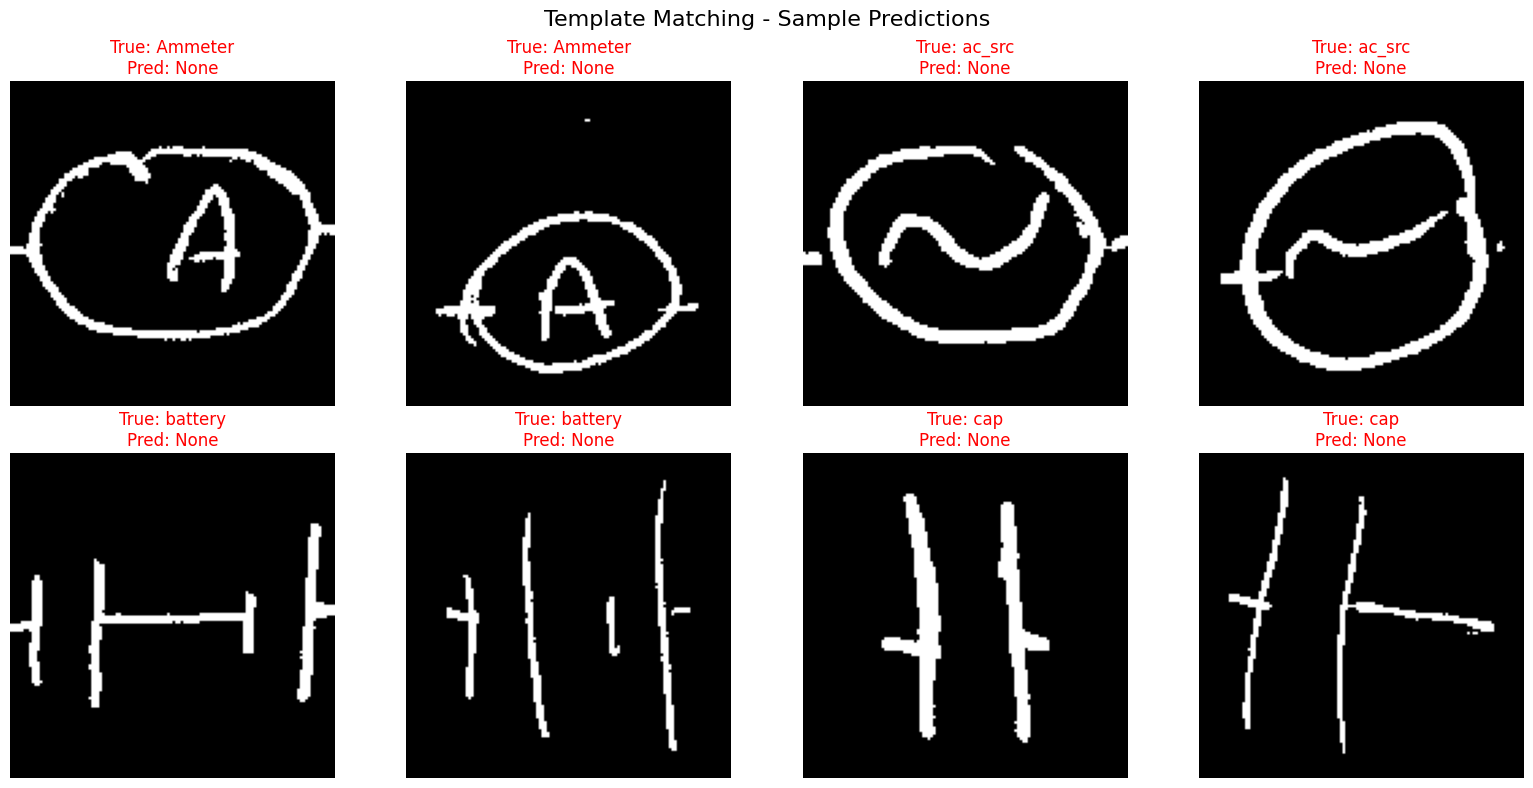

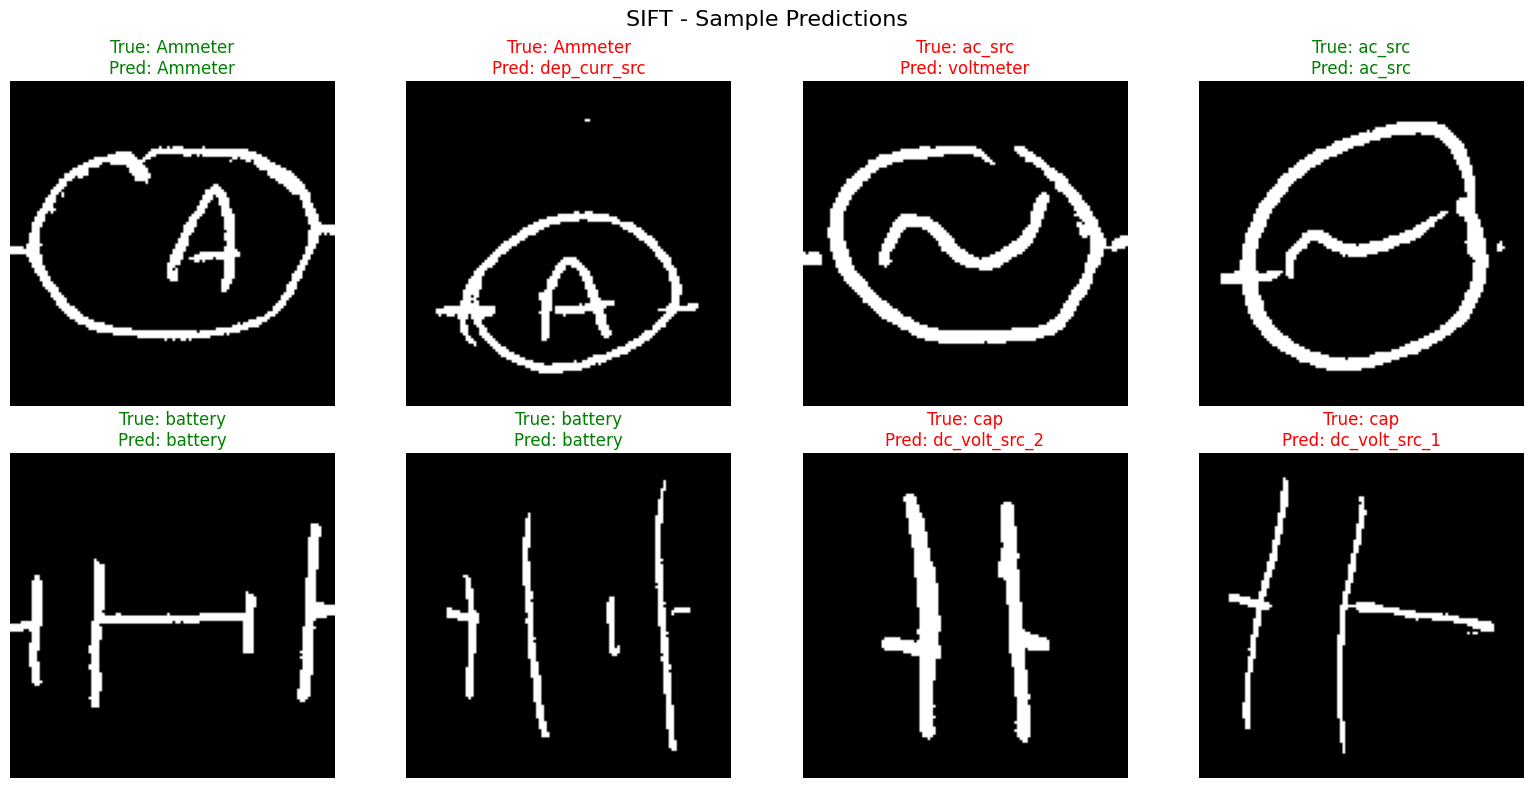

In [ ]:
def visualize_predictions(classifier, test_dir, model_name, num_samples=8):

    test_path = Path(test_dir)
    sample_images = []

    for class_name in class_to_idx.keys():
        class_dir = test_path / class_name
        if class_dir.exists():
            imgs = []
            for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp']:
                imgs.extend(list(class_dir.glob(ext))[:2])
            sample_images.extend([(img, class_name) for img in imgs[:2]])

    sample_images = sample_images[:num_samples]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for idx, (img_path, true_label) in enumerate(sample_images):
        pred_label, score = classifier.predict(img_path)

        img = cv2.imread(str(img_path))
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[idx].imshow(img_rgb)
            color = 'green' if pred_label == true_label else 'red'
            axes[idx].set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
            axes[idx].axis('off')

    plt.suptitle(f'{model_name} - Sample Predictions', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'results/{model_name.lower().replace(" ", "_")}/sample_predictions.png',
                dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(tm_classifier, 'data/processed/test', 'Template Matching')
visualize_predictions(sift_classifier, 'data/processed/test', 'SIFT')

In [ ]:
baseline_summary = {
    'template_matching': {
        'accuracy': float(tm_results['accuracy']),
        'precision': float(tm_results['precision']),
        'recall': float(tm_results['recall']),
        'f1_score': float(tm_results['f1_score'])
    },
    'sift': {
        'accuracy': float(sift_results['accuracy']),
        'precision': float(sift_results['precision']),
        'recall': float(sift_results['recall']),
        'f1_score': float(sift_results['f1_score'])
    }
}

with open('results/baseline_summary.json', 'w') as f:
    json.dump(baseline_summary, f, indent=2) 


# CNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from tqdm import tqdm
import pickle
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

with open('data/class_mapping.json', 'r') as f:
    class_data = json.load(f)
    class_to_idx = class_data['class_to_idx']
    idx_to_class = {int(k): v for k, v in class_data['idx_to_class'].items()}

num_classes = len(class_to_idx)
print(f"Number of classes: {num_classes}")

Using device: cuda
GPU: Tesla T4
Number of classes: 15


In [ ]:
class CircuitSymbolDataset(Dataset):

    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.images = []
        self.labels = []
        for class_name, class_idx in class_to_idx.items():
            class_dir = self.data_dir / class_name
            if class_dir.exists():
                for ext in ['*.png', '*.jpg', '*.bmp', '*.BMP']:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(class_idx)

        print(f"Loaded {len(self.images)} images from {data_dir}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [ ]:

train_dataset = CircuitSymbolDataset('data/processed/train', transform=train_transform)
val_dataset = CircuitSymbolDataset('data/processed/val', transform=val_transform)
test_dataset = CircuitSymbolDataset('data/processed/test', transform=val_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\nDataLoader Info:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Loaded 2062 images from data/processed/train
Loaded 443 images from data/processed/val
Loaded 447 images from data/processed/test

DataLoader Info:
  Train batches: 65
  Val batches: 14
  Test batches: 14


In [ ]:
class CircuitCNN(nn.Module):

    def __init__(self, num_classes, pretrained=True):
        super(CircuitCNN, self).__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = CircuitCNN(num_classes=num_classes, pretrained=True)
model = model.to(device)

print(f"\n{model.__class__.__name__} initialized")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]



CircuitCNN initialized
Total parameters: 11,311,695
Trainable parameters: 11,311,695


In [ ]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                  factor=0.5, patience=3)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}


In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': running_loss/len(pbar),'acc': 100*correct/total})

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [ ]:
num_epochs = 25
best_val_acc = 0.0
patience_counter = 0
early_stopping_patience = 7

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step(val_acc)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'models/cnn/best_model.pth')
        print(f"✓ Best model saved! (Val Acc: {val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

training_time = time.time() - start_time
print(f"\n✓ Training completed in {training_time/60:.2f} minutes")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

torch.save(model.state_dict(), 'models/cnn/final_model.pth')

with open('results/cnn/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)


STARTING TRAINING

Epoch 1/25
----------------------------------------


Validation: 100%|██████████| 14/14 [00:03<00:00,  4.36it/s]


Train Loss: 1.0146 | Train Acc: 66.63%
Val Loss: 2.4292 | Val Acc: 53.95%
✓ Best model saved! (Val Acc: 53.95%)

Epoch 2/25
----------------------------------------


Validation: 100%|██████████| 14/14 [00:02<00:00,  5.50it/s]


Train Loss: 0.4788 | Train Acc: 84.72%
Val Loss: 0.3477 | Val Acc: 88.71%
✓ Best model saved! (Val Acc: 88.71%)

Epoch 3/25
----------------------------------------


...

Train Loss: 0.0512 | Train Acc: 98.35%
Val Loss: 0.0317 | Val Acc: 99.10%
✓ Best model saved! (Val Acc: 99.10%)

Epoch 24/25
----------------------------------------


Validation: 100%|██████████| 14/14 [00:02<00:00,  5.64it/s]


Train Loss: 0.0556 | Train Acc: 98.45%
Val Loss: 0.0580 | Val Acc: 98.19%

Epoch 25/25
----------------------------------------


Validation: 100%|██████████| 14/14 [00:03<00:00,  4.09it/s]


Train Loss: 0.0399 | Train Acc: 98.84%
Val Loss: 0.0505 | Val Acc: 98.87%

✓ Training completed in 8.25 minutes
Best validation accuracy: 99.10%


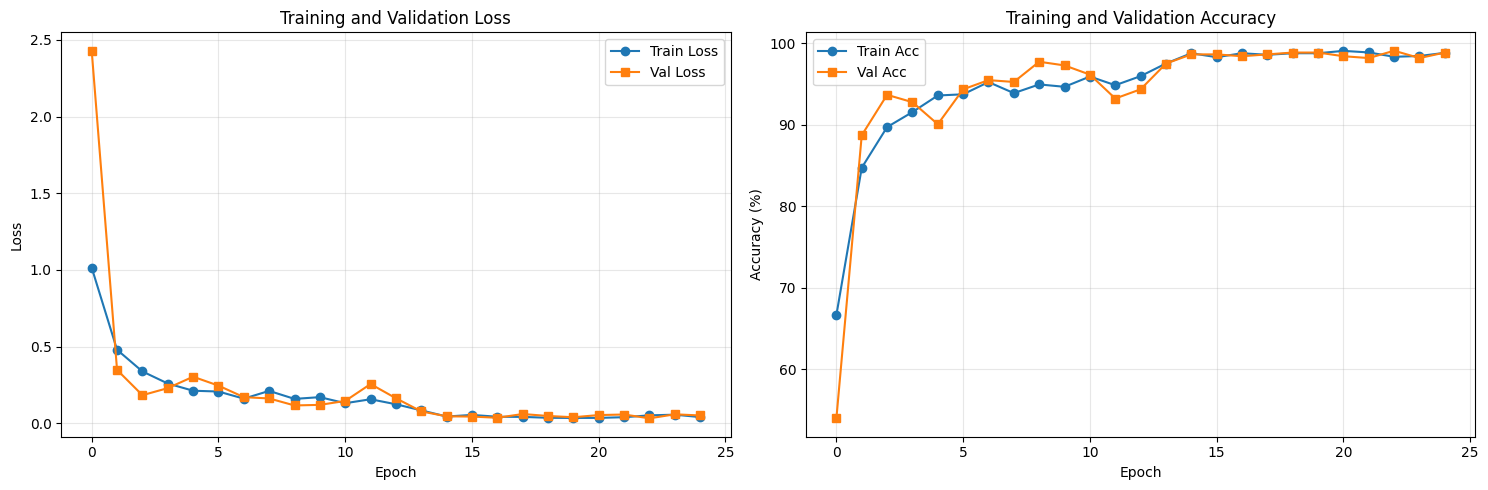

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/cnn/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

model.load_state_dict(torch.load('models/cnn/best_model.pth'))
model.eval()

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

y_true = []
y_pred = []
y_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())


accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

cnn_results = {
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'training_time_minutes': float(training_time/60),
    'best_val_accuracy': float(best_val_acc)
}

with open('results/cnn/test_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)



EVALUATING ON TEST SET


Testing: 100%|██████████| 14/14 [00:04<00:00,  3.20it/s]


Test Accuracy: 98.21%
Precision: 0.9831
Recall: 0.9821
F1-Score: 0.9821


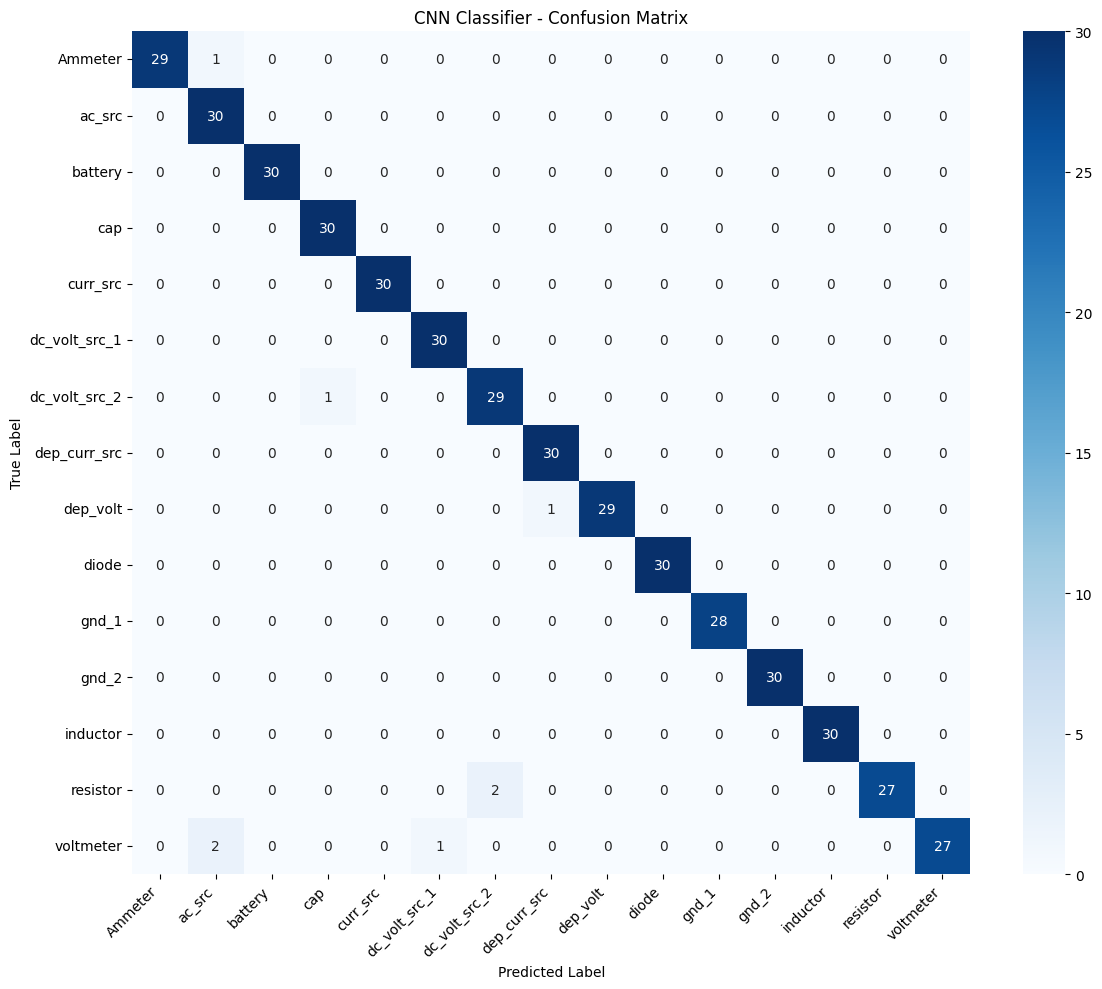

In [70]:
cm = confusion_matrix(y_true, y_pred)
class_names = [idx_to_class[i] for i in range(num_classes)]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Classifier - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('results/cnn/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
with open('results/cnn/classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)


CLASSIFICATION REPORT
               precision    recall  f1-score   support

      Ammeter       1.00      0.97      0.98        30
       ac_src       0.91      1.00      0.95        30
      battery       1.00      1.00      1.00        30
          cap       0.97      1.00      0.98        30
     curr_src       1.00      1.00      1.00        30
dc_volt_src_1       0.97      1.00      0.98        30
dc_volt_src_2       0.94      0.97      0.95        30
 dep_curr_src       0.97      1.00      0.98        30
     dep_volt       1.00      0.97      0.98        30
        diode       1.00      1.00      1.00        30
        gnd_1       1.00      1.00      1.00        28
        gnd_2       1.00      1.00      1.00        30
     inductor       1.00      1.00      1.00        30
     resistor       1.00      0.93      0.96        29
    voltmeter       1.00      0.90      0.95        30

     accuracy                           0.98       447
    macro avg       0.98      0.98      

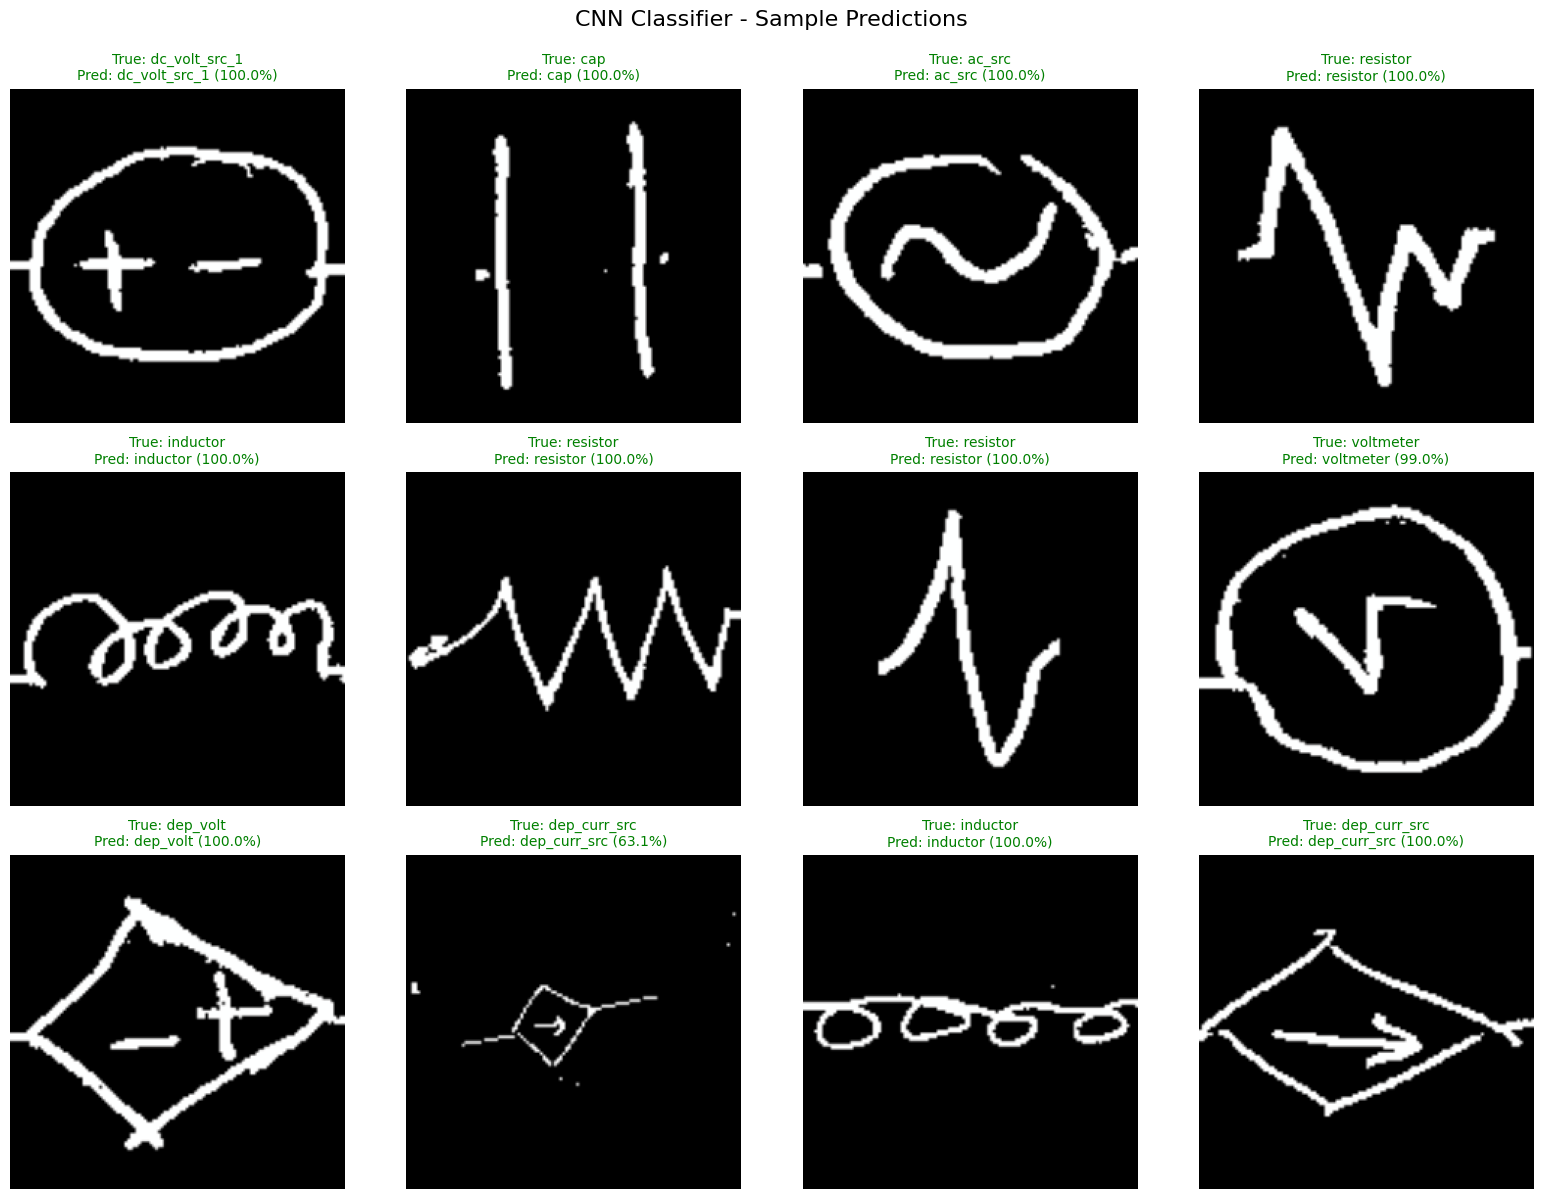

In [ ]:
def visualize_predictions_cnn(model, dataset, num_samples=12):
    """
    Visualize sample predictions
    """
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            image, true_label = dataset[idx]

            image_batch = image.unsqueeze(0).to(device)
            output = model(image_batch)
            prob = torch.softmax(output, dim=1)
            pred_prob, pred_label = torch.max(prob, 1)

            img_display = image.cpu().numpy().transpose(1, 2, 0)
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_display = std * img_display + mean
            img_display = np.clip(img_display, 0, 1)

            ax.imshow(img_display)
            true_class = idx_to_class[true_label]
            pred_class = idx_to_class[pred_label.item()]
            color = 'green' if true_label == pred_label.item() else 'red'

            ax.set_title(f'True: {true_class}\nPred: {pred_class} ({pred_prob.item()*100:.1f}%)',
                        color=color, fontsize=10)
            ax.axis('off')

    plt.suptitle('CNN Classifier - Sample Predictions', fontsize=16, y=0.995)
    plt.tight_layout()
    plt.savefig('results/cnn/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions_cnn(model, test_dataset, num_samples=12)

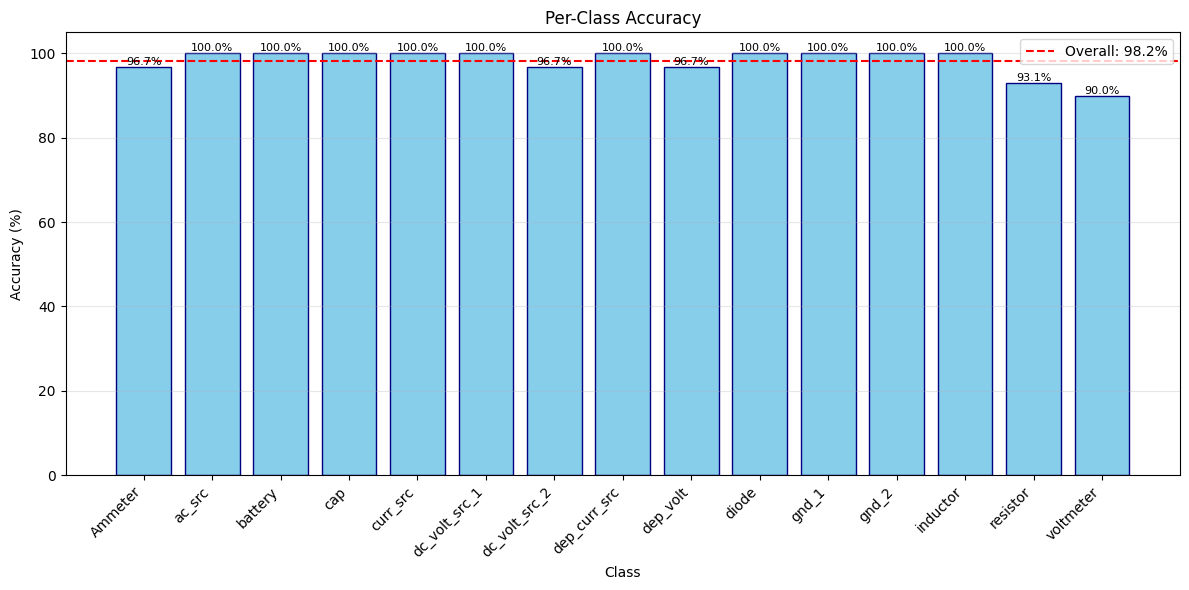

In [ ]:
per_class_acc = {}
for i in range(num_classes):
    class_mask = np.array(y_true) == i
    if class_mask.sum() > 0:
        class_acc = accuracy_score(
            np.array(y_true)[class_mask],
            np.array(y_pred)[class_mask]
        )
        per_class_acc[idx_to_class[i]] = class_acc

fig, ax = plt.subplots(figsize=(12, 6))
classes = list(per_class_acc.keys())
accuracies = [per_class_acc[c]*100 for c in classes]

bars = ax.bar(range(len(classes)), accuracies, color='skyblue', edgecolor='navy')
ax.set_xlabel('Class')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy')
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.axhline(y=accuracy*100, color='r', linestyle='--', label=f'Overall: {accuracy*100:.1f}%')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results/cnn/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

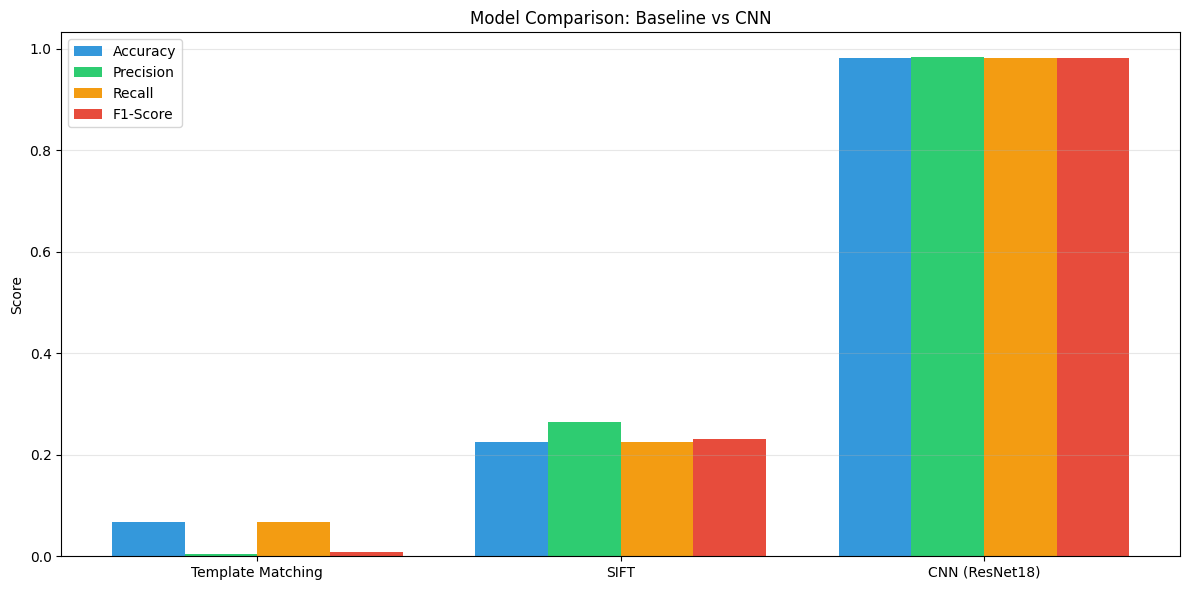


MODEL COMPARISON
            Model  Accuracy  Precision   Recall  F1-Score
Template Matching  0.067114   0.004504 0.067114  0.008442
             SIFT  0.225951   0.263850 0.225951  0.230563
   CNN (ResNet18)  0.982103   0.983074 0.982103  0.982078

CNN TRAINING AND EVALUATION COMPLETE! ✓
Models saved:
  - models/cnn/best_model.pth
  - models/cnn/final_model.pth

Results saved:
  - results/cnn/test_results.json
  - results/cnn/training_history.json
  - results/cnn/classification_report.json

Next step: Run YOLO Detection notebook


In [ ]:

with open('results/baseline_summary.json', 'r') as f:
    baseline_results = json.load(f)

comparison = {
    'Model': ['Template Matching', 'SIFT', 'CNN (ResNet18)'],
    'Accuracy': [
        baseline_results['template_matching']['accuracy'],
        baseline_results['sift']['accuracy'],
        accuracy
    ],
    'Precision': [
        baseline_results['template_matching']['precision'],
        baseline_results['sift']['precision'],
        precision
    ],
    'Recall': [
        baseline_results['template_matching']['recall'],
        baseline_results['sift']['recall'],
        recall
    ],
    'F1-Score': [
        baseline_results['template_matching']['f1_score'],
        baseline_results['sift']['f1_score'],
        f1
    ]
}

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison['Model']))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison[metric], width, label=metric, color=colors[i])

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Baseline vs CNN')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/cnn/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


import pandas as pd
df_comparison = pd.DataFrame(comparison)
df_comparison.to_csv('results/cnn/model_comparison.csv', index=False)

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(df_comparison.to_string(index=False))
print("="*60)

print("\n" + "="*60)
print("CNN TRAINING AND EVALUATION COMPLETE! ✓")
print("="*60)
print("Models saved:")
print("  - models/cnn/best_model.pth")
print("  - models/cnn/final_model.pth")
print("\nResults saved:")
print("  - results/cnn/test_results.json")
print("  - results/cnn/training_history.json")
print("  - results/cnn/classification_report.json")
print("\nNext step: Run YOLO Detection notebook")
print("="*60)

#YOLO


In [ ]:
import torch
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from tqdm import tqdm
import shutil
import os
import time
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


try:
    with open('data/class_mapping.json', 'r') as f:
        class_data = json.load(f)
        class_to_idx = class_data['class_to_idx']
        idx_to_class = {int(k): v for k, v in class_data['idx_to_class'].items()}
except FileNotFoundError:
    print("Error: data/class_mapping.json not found. Run setup notebook first.")
    exit()

num_classes = len(class_to_idx)
class_names = [idx_to_class[i] for i in range(num_classes)]


YOLO_DATA_ROOT = Path('data/yolo_format')
PROCESSED_DATA_ROOT = Path('data/processed')


def create_yolo_labels_v5(split_name, target_img_dir, target_lbl_dir):
    target_img_dir.mkdir(parents=True, exist_ok=True)
    target_lbl_dir.mkdir(parents=True, exist_ok=True)
    source_path = PROCESSED_DATA_ROOT / split_name
    count = 0

    print(f"\n[YOLO Data] Preparing {split_name} dummy labels...")

    for class_name, class_idx in tqdm(class_to_idx.items()):
        class_dir = source_path / class_name
        if not class_dir.exists(): continue

        for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.BMP']:
            for img_path in class_dir.glob(ext):
                shutil.copy2(img_path, target_img_dir / img_path.name)

                yolo_label = f"{class_idx} 0.5 0.5 1.0 1.0"
                label_filename = img_path.stem + '.txt'

                with open(target_lbl_dir / label_filename, 'w') as f:
                    f.write(yolo_label)

                count += 1
    return count

for d in ['images/train', 'labels/train', 'images/val', 'labels/val', 'images/test', 'labels/test']:
    shutil.rmtree(YOLO_DATA_ROOT / d, ignore_errors=True)
    (YOLO_DATA_ROOT / d).mkdir(parents=True, exist_ok=True)

create_yolo_labels_v5('train', YOLO_DATA_ROOT / 'images/train', YOLO_DATA_ROOT / 'labels/train')
create_yolo_labels_v5('val', YOLO_DATA_ROOT / 'images/val', YOLO_DATA_ROOT / 'labels/val')
create_yolo_labels_v5('test', YOLO_DATA_ROOT / 'images/test', YOLO_DATA_ROOT / 'labels/test') 

data_yaml_content = f"""
path: {YOLO_DATA_ROOT.resolve()}
train: images/train
val: images/val
test: images/test

# Classes
nc: {num_classes}
names: {class_names}
"""

with open(YOLO_DATA_ROOT / 'data.yaml', 'w') as f:
    f.write(data_yaml_content)

print("\n✓ data/yolo_format/data.yaml created!")




Using device: cuda
GPU: Tesla T4

[YOLO Data] Preparing train dummy labels...


100%|██████████| 15/15 [00:41<00:00,  2.74s/it]



[YOLO Data] Preparing val dummy labels...


100%|██████████| 15/15 [00:08<00:00,  1.83it/s]



[YOLO Data] Preparing test dummy labels...


100%|██████████| 15/15 [00:08<00:00,  1.87it/s]


✓ data/yolo_format/data.yaml created!


In [ ]:
print("\n" + "="*60)
print("STARTING YOLOv5s TRAINING (Maximized Accuracy Config)")
print("="*60)

model = YOLO('yolov5s.pt')

imgsz = 640 
epochs = 100 
patience = 20 
model_run_name = 'yolov5s_max_acc'

start_time = time.time()

results = model.train(
    data=YOLO_DATA_ROOT / 'data.yaml',
    imgsz=imgsz,
    epochs=epochs,
    patience=patience,
    batch=8, 
    name=model_run_name,
    project='models/yolo_runs',
    exist_ok=True,
    device=device,
)

training_time = time.time() - start_time
print(f"\n✓ YOLOv5s Training completed in {training_time/60:.2f} minutes")

yolo_run_path = Path('models/yolo_runs') / model_run_name
best_model_path = yolo_run_path / 'weights' / 'best.pt'
shutil.copy(best_model_path, 'models/yolo/best_yolov5_model.pt')


STARTING YOLOv5s TRAINING (Maximized Accuracy Config)
PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.3.213 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/yolo_format/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False,

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1357: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1359: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.6±0.2 ms, read: 9.2±3.1 MB/s, size: 15.1 KB)
train: Scanning /content/drive/MyDrive/circuit_detection_project/data/yolo_format/labels/train.cache... 197 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 197/197 114.4Kit/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 1.1±0.3 ms, read: 1.5±1.2 MB/s, size: 20.5 KB)
val: Scanning /content/drive/MyDrive/circuit_detection_project/data/yolo_format/labels/val.cache... 122 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 122/122 26.7Kit/s 0.0s
Plotting labels to /content/drive/MyDrive/circuit_detection_project/models/yolo_runs/yolov5s_max_acc/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momen

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:240: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      1/100      2.38G       2.55      4.533       3.01         15        640: 100% ━━━━━━━━━━━━ 25/25 4.6it/s 5.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.2it/s 3.6s
                   all        122        122      0.914       0.03     0.0172    0.00765

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100       2.7G      1.849      2.789      2.381         22        640: 0% ──────────── 0/25  0.2s

...

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:240: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


     84/100      2.81G     0.4907     0.5841      1.199         15        640: 100% ━━━━━━━━━━━━ 25/25 6.1it/s 4.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 7.0it/s 1.1s
                   all        122        122      0.587      0.515      0.548      0.512

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/100      2.81G     0.5183      0.561      1.261         23        640: 0% ──────────── 0/25  0.1s

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:240: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


     85/100      2.81G     0.5189     0.5459      1.238         14        640: 100% ━━━━━━━━━━━━ 25/25 4.3it/s 5.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 6.9it/s 1.2s
                   all        122        122      0.563      0.544       0.55      0.505
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 65, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

85 epochs completed in 0.154 hours.
Optimizer stripped from /content/drive/MyDrive/circuit_detection_project/models/yolo_runs/yolov5s_max_acc/weights/last.pt, 18.5MB
Optimizer stripped from /content/drive/MyDrive/circuit_detection_project/models/yolo_runs/yolov5s_max_acc/weights/best.pt, 18.5MB

Validating /content/drive/MyDrive/circuit_detection_project/models/yolo_runs/yolov5s_max_acc/w

'models/yolo/best_yolov5_model.pt'

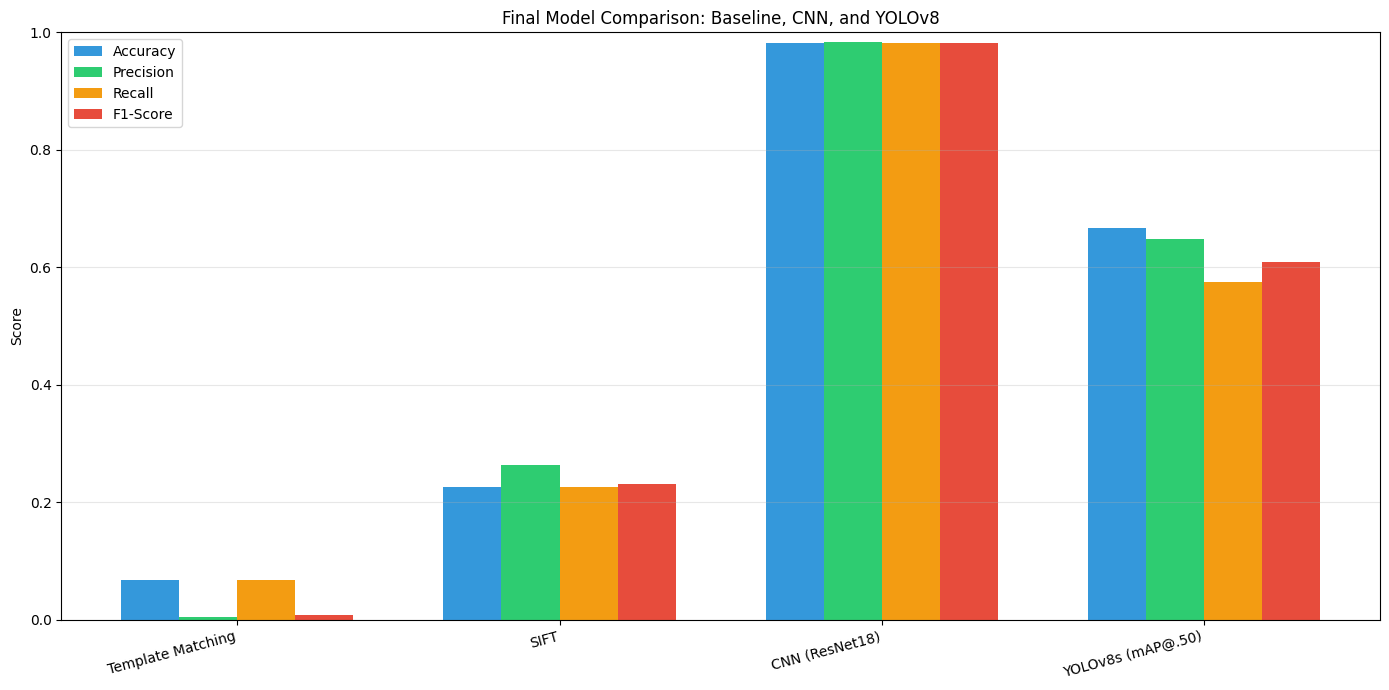


FINAL MODEL COMPARISON (4 Models)
            Model  Accuracy  Precision   Recall  F1-Score
Template Matching  0.067114   0.004504 0.067114  0.008442
             SIFT  0.225951   0.263850 0.225951  0.230563
   CNN (ResNet18)  0.982103   0.983074 0.982103  0.982078
YOLOv8s (mAP@.50)  0.667188   0.648616 0.574638  0.609390

PROJECT COMPLETE! ✓
All models trained and final comparison generated.


In [ ]:


import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    with open('results/baseline_summary.json', 'r') as f:
        baseline_results = json.load(f)
except FileNotFoundError:
    print("Error: Baseline summary not found. Ensure baseline_models.py was run.")
    baseline_results = {'template_matching': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1_score': 0},
                        'sift': {'accuracy': 0, 'precision': 0, 'recall': 0, 'f1_score': 0}}

try:
    with open('results/yolo/test_results.json', 'r') as f:
        yolo_results = json.load(f)
    yolo_score = yolo_results['mAP50']
    yolo_precision = yolo_results['precision']
    yolo_recall = yolo_results['recall']
except FileNotFoundError:
    print("Error: YOLO results not found. Ensure YOLO training/evaluation was run.")
    yolo_score = 0
    yolo_precision = 0
    yolo_recall = 0

try:
    with open('results/cnn/test_results.json', 'r') as f:
        cnn_results = json.load(f)
    cnn_accuracy = cnn_results['accuracy']
    cnn_precision = cnn_results['precision']
    cnn_recall = cnn_results['recall']
    cnn_f1 = cnn_results['f1_score']
except FileNotFoundError:
    print("Error: CNN test results not found. Using Placeholder.")
    cnn_accuracy = 0.0 
    cnn_precision = 0.0
    cnn_recall = 0.0
    cnn_f1 = 0.0

if yolo_precision + yolo_recall > 0:
    yolo_f1 = 2 * (yolo_precision * yolo_recall) / (yolo_precision + yolo_recall)
else:
    yolo_f1 = 0

comparison = {
    'Model': ['Template Matching', 'SIFT', 'CNN (ResNet18)', 'YOLOv8s (mAP@.50)'],
    'Accuracy/mAP': [
        baseline_results['template_matching']['accuracy'],
        baseline_results['sift']['accuracy'],
        cnn_accuracy,
        yolo_score
    ],
    'Precision': [
        baseline_results['template_matching']['precision'],
        baseline_results['sift']['precision'],
        cnn_precision,
        yolo_precision
    ],
    'Recall': [
        baseline_results['template_matching']['recall'],
        baseline_results['sift']['recall'],
        cnn_recall,
        yolo_recall
    ],
    'F1-Score': [
        baseline_results['template_matching']['f1_score'],
        baseline_results['sift']['f1_score'],
        cnn_f1,
        yolo_f1
    ]
}

df_comparison = pd.DataFrame(comparison)
df_comparison.rename(columns={'Accuracy/mAP': 'Accuracy'}, inplace=True) 
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_comparison['Model']))
width = 0.18 

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, df_comparison[metric], width, label=metric, color=colors[i])

ax.set_ylabel('Score')
ax.set_title('Final Model Comparison: Baseline, CNN, and YOLOv8')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_comparison['Model'], rotation=15, ha='right')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0) 
plt.tight_layout()
plt.savefig('results/final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

df_comparison.to_csv('results/final_model_comparison.csv', index=False)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON (4 Models)")
print("="*60)
print(df_comparison.to_string(index=False))
print("="*60)

print("\n" + "="*60)
print("PROJECT COMPLETE! ✓")
print("="*60)
print("All models trained and final comparison generated.")
print("="*60)